=== BASELINE MLP CLASSIFIER ===
Accuracy: 0.767
F1 Score: 0.7838
Runtime: 6.9 seconds
--------------------------------------------------
--- Tuning Parameter Set 1 ---
Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,)}
Accuracy: 0.7767, F1 Score: 0.7928, Runtime: 46.18s

--- Tuning Parameter Set 2 ---
Best Params: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50)}
Accuracy: 0.7816, F1 Score: 0.8035, Runtime: 26.06s

--- Tuning Parameter Set 3 ---
Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (150,)}
Accuracy: 0.7816, F1 Score: 0.7982, Runtime: 45.13s



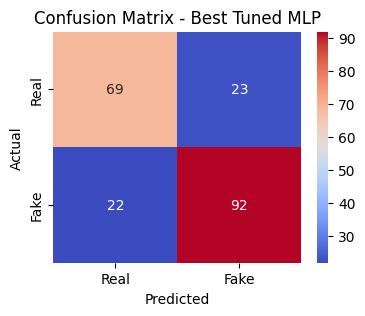


=== MLP MODEL COMPARISON ===
        Set                                        Best Params  Accuracy  \
0  Baseline                                            Default    0.7670   
1         1  {'activation': 'relu', 'alpha': 0.001, 'hidden...    0.7767   
2         2  {'activation': 'tanh', 'alpha': 0.001, 'hidden...    0.7816   
3         3  {'activation': 'relu', 'alpha': 0.001, 'hidden...    0.7816   

   F1 Score  Runtime (s)  
0    0.7838         6.90  
1    0.7928        46.18  
2    0.8035        26.06  
3    0.7982        45.13  

=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===
[0.79787234 0.8        0.79787234 0.81355932 0.8       ]
Mean CV F1 Score: 0.8019


In [2]:
# MODEL 4: MLP NEURAL NETWORK CLASSIFIER

import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("final_preprocessed_vectorized.csv")

# Features and target
tfidf_cols = [c for c in df.columns if c.startswith('tfidf_')]
X = df[tfidf_cols]
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Baseline MLP
mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
start = time.time()
mlp_base.fit(X_train_s, y_train)
yp_base = mlp_base.predict(X_test_s)
end = time.time()
baseline_runtime = round(end - start, 2)

print("=== BASELINE MLP CLASSIFIER ===")
print("Accuracy:", round(accuracy_score(y_test, yp_base),4))
print("F1 Score:", round(f1_score(y_test, yp_base),4))
print("Runtime:", baseline_runtime, "seconds")
print("-"*50)

# Parameter tuning
param_sets = [
    {'hidden_layer_sizes': [(50,), (100,)], 'activation': ['relu'], 'alpha': [0.0001, 0.001]},
    {'hidden_layer_sizes': [(100,50), (50,50)], 'activation': ['tanh'], 'alpha': [0.0001, 0.001]},
    {'hidden_layer_sizes': [(100,), (150,)], 'activation': ['relu'], 'alpha': [0.001, 0.01]}
]

best_score = 0
best_model = None
best_params = None
tuning_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for i, params in enumerate(param_sets, 1):
    print(f"--- Tuning Parameter Set {i} ---")
    mlp_model = MLPClassifier(max_iter=300, random_state=42)

    start = time.time()
    grid = GridSearchCV(mlp_model, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    end = time.time()
    runtime = round(end - start, 2)

    yp = grid.predict(X_test_s)
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp)

    tuning_results.append({
        'Set': i,
        'Best Params': grid.best_params_,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4),
        'Runtime (s)': runtime
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {round(acc,4)}, F1 Score: {round(f1,4)}, Runtime: {runtime}s\n")

    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_params = grid.best_params_

# Confusion Matrix for Best Tuned Model
yp_best = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("Confusion Matrix - Best Tuned MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison Table
comparison_df = pd.DataFrame(tuning_results)
baseline_row = pd.DataFrame([{
    'Set': 'Baseline',
    'Best Params': 'Default',
    'Accuracy': round(accuracy_score(y_test, yp_base),4),
    'F1 Score': round(f1_score(y_test, yp_base),4),
    'Runtime (s)': baseline_runtime
}])
comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print("\n=== MLP MODEL COMPARISON ===")
print(comparison_df)

# Cross-validation on Best Tuned Model
cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring='f1')
print("\n=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===")
print(cv_scores)
print("Mean CV F1 Score:", round(np.mean(cv_scores),4))
